# seege_ usage tutorial 
for synthetic EEG evaluation

#### 1. Imports and basic setup

In [1]:
import pickle
from preprocessing import *
from amplitude_fidelity import *
from frequency_fidelity import *
from time_frequency_fidelity import *
from complexity_fidelity import *
from time_fidelity import *
from diversity2 import *
from privacy import *
import evaluation_score
from itertools import product
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3), dpi=100)
import seaborn as sns

sns.set_theme(style='whitegrid', rc={
    'figure.figsize': (6, 3),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

Data processed.


<Figure size 600x300 with 0 Axes>

#### 2. Data preprocessing

1. Load data
2. Downsampling
3. Normalization

#### 2.1. Load data

(5, 20, 1536)
(5, 20, 1536)


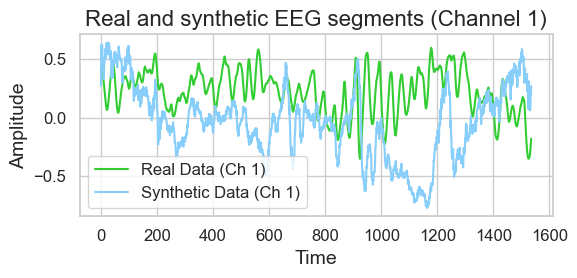

In [2]:
real_data = load_pickle("data/5_real_examples.pkl")
synthetic_data = load_pickle("data/5_synthetic_examples.pkl")

# Print data shape
print(np.shape(real_data))
print(np.shape(synthetic_data))

# This evaluation is for sparse signals, assumes shape (n_samples, n_points)
real_seg = real_data[0]         # shape (20, 1536)
synth_seg = synthetic_data[0]   # shape (20, 1536)

real_ch0 = real_seg[8, :]       # shape (1536,)
synth_ch0 = synth_seg[8, :]     # shape (1536,)

plt.figure(figsize=(6, 3), facecolor=plt.rcParams['figure.facecolor'])

ax = sns.lineplot(
    x=range(len(real_ch0)),
    y=real_ch0,
    color="limegreen",
    label="Real Data (Ch 1)"
)

sns.lineplot(
    x=range(len(synth_ch0)),
    y=synth_ch0,
    color="lightskyblue",
    label="Synthetic Data (Ch 1)",
    ax=ax
)

ax.set_title("Real and synthetic EEG segments (Channel 1)")
ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")
ax.legend()
plt.tight_layout()
plt.show()


#### 3. Fidelity evaluation


#### 3.1. Amplitude fidelity

ADM: 1.695, FDM: 1.754, GDM: 2.439, Similarity: 0.087  | mode:all_vs_all, pairs:400


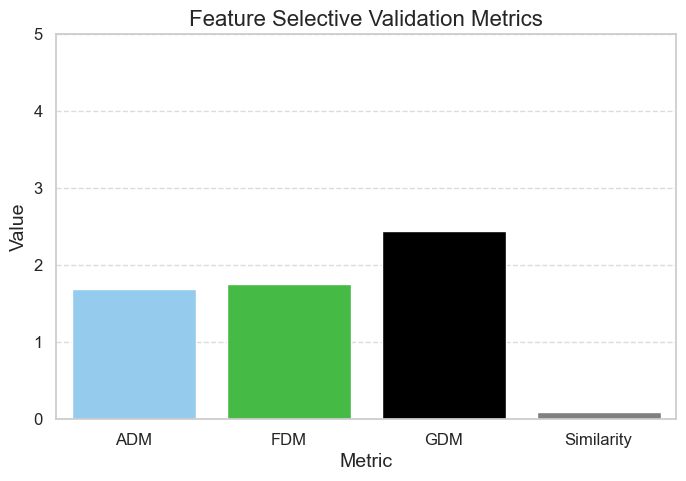

ADM: 1.695, FDM: 1.754, GDM: 2.439, Similarity: 0.087  | mode:all_vs_all, pairs:400
Amplitude Fidelity Score: 0.09


In [3]:
# Initialize class
asim = AmplitudeFidelity(fs=512)
# Compute amplitude similarity metrics
amplitude_dataset = asim.compute_amplitude_metrics(real_seg, synth_seg)
#amplitude_sample = asim.compute_metrics(real_seg[0], synth_seg[0])

# Plot amplitude similarity metrics
dataset_plot = asim.plot_amplitude_metrics(amplitude_dataset)
#sample_plot = asim.plot_metrics(amplitude_sample)

# Compute amplitude similarity score
dataset_score = evaluation_score.compute_amplitude_fidelity_score(real_seg, synth_seg, fs=512)
#sample_score = evaluation_score.compute_amplitude_fidelity_score(real_seg[0], synth_seg[0], fs=512)

#### 3.2. Time fidelity

=== Mean Hjorth Parameters ===
Real Signals: Activity=0.0587, Mobility=0.1080, Complexity=3.4704
Synthetic Signals: Activity=0.0480, Mobility=0.2908, Complexity=5.9340
=== Hjorth Parameters Summary ===
Activity - Wasserstein Distance: 0.0108
Mobility - Wasserstein Distance: 0.1828
Complexity - Wasserstein Distance: 2.4636
Average Wasserstein Distance: 0.8857
Mahalanobis Distance: 1.9272



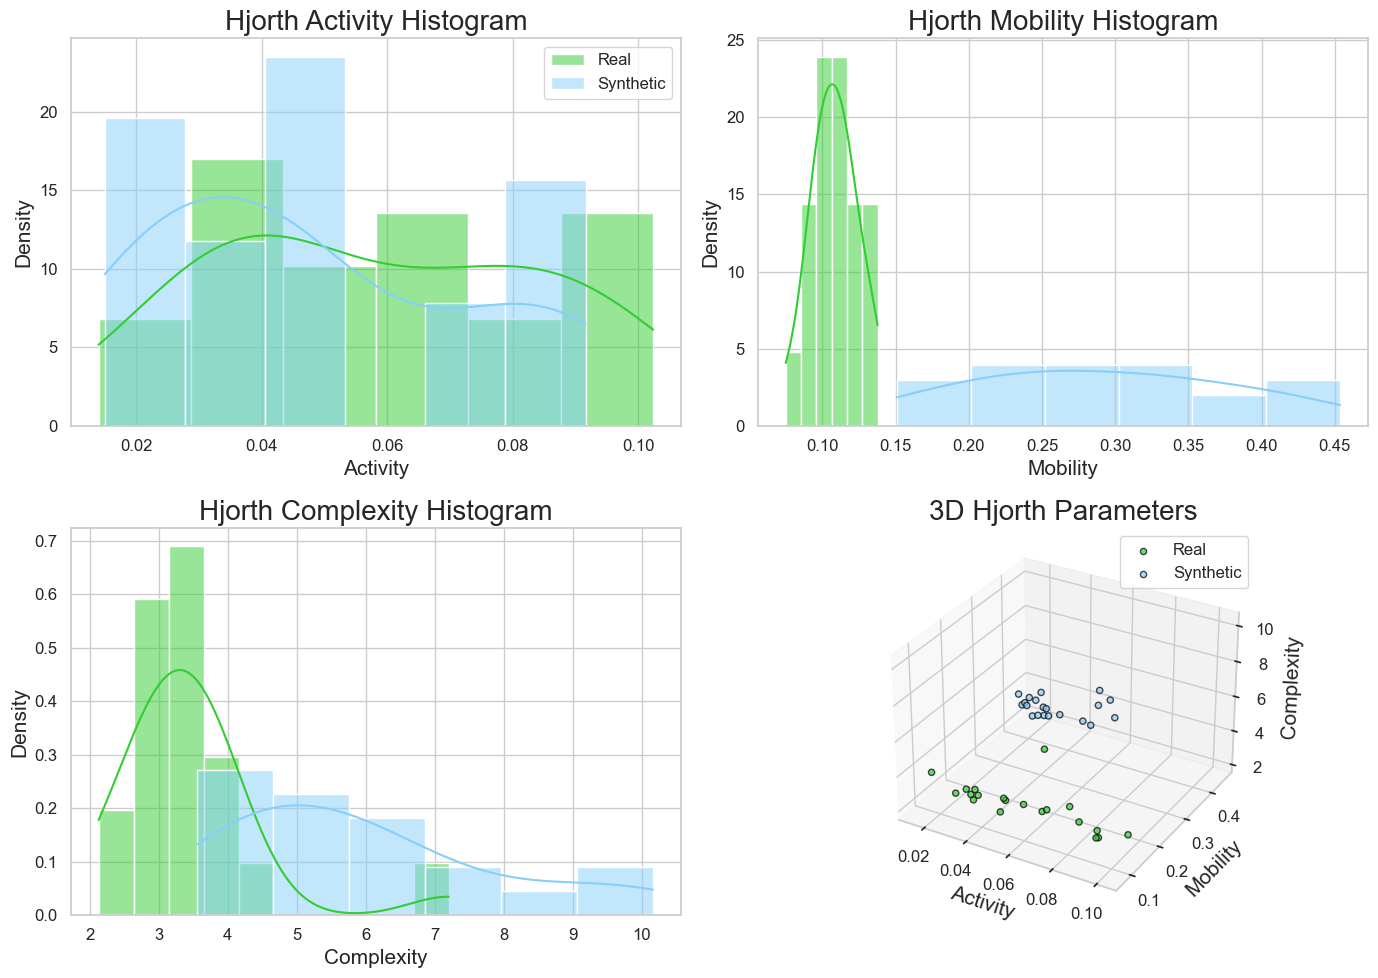

Time Fidelity Score  : 0.616
Time Fidelity Components:
  Activity: 0.989
  Mobility: 0.845
  Complexity: 0.289
  Mahalanobis: 0.342


0.6162927809575466

In [4]:
# Initialize class
sim = TimeFidelity()
# Compute Hjorth metrics
hjorth_dataset = sim.compute_hjorth_metrics(real_seg, synth_seg, verbose=True)

# Plot Hjorth metrics
hjorth_figures = sim.plot_hjorth_metrics(real_seg, synth_seg)

# Compute time fidelity score
evaluation_score.compute_time_fidelity_score(real_seg, synth_seg)

#### 3.3. Frequency fidelity

Relative Bands Power (Dataset):
  Delta: Real: 32.22%, Synthetic: 30.23%, Diff: 1.99%
  Theta: Real: 5.38%, Synthetic: 17.74%, Diff: 12.37%
  Alpha: Real: 25.79%, Synthetic: 12.76%, Diff: 13.03%
  Beta: Real: 17.46%, Synthetic: 17.52%, Diff: 0.06%
  Gamma: Real: 0.55%, Synthetic: 3.49%, Diff: 2.95%
  Ripple: Real: 0.02%, Synthetic: 3.18%, Diff: 3.16%
  Fast Ripple: Real: 0.00%, Synthetic: 0.17%, Diff: 0.17%
Statistical Test Results (Dataset):
  Delta: Test=Paired t-test, Stat=0.511, p-value=0.615, Cohen's d=0.114
  Theta: Test=Paired t-test, Stat=-6.247, p-value=< 0.001 (exact=5.34e-06), Cohen's d=-1.397
  Alpha: Test=Paired t-test, Stat=7.149, p-value=< 0.001 (exact=8.54e-07), Cohen's d=1.599
  Beta: Test=Wilcoxon signed-rank test, Stat=76.000, p-value=0.294, Cohen's d=-0.004
  Gamma: Test=Paired t-test, Stat=-7.452, p-value=< 0.001 (exact=4.73e-07), Cohen's d=-1.666
  Ripple: Test=Paired t-test, Stat=-9.641, p-value=< 0.001 (exact=9.45e-09), Cohen's d=-2.156
  Fast Ripple: Test=Wilco

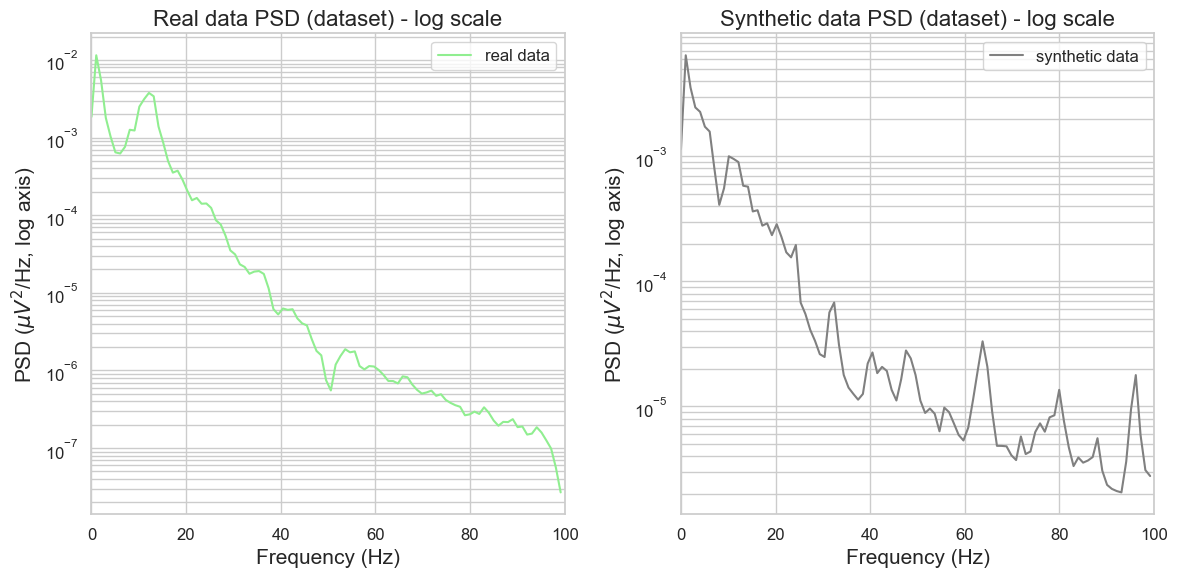

Mode: all_vs_all | RS spectral coherence=0.340 (± 0.021) (dataset)
RR  | Spectral coherence = 0.390 ± 0.055
SS  | Spectral coherence = 0.460 ± 0.035
RS  | Spectral coherence = 0.340 ± 0.021
Spectral Wasserstein distance (Hz) [0.5-100.0]: 4.0401
Frequency Fidelity Score: 0.58


0.5796408588884855

In [5]:
# Initialize class
frequency_analysis = FrequencyFidelity(fs=512)
# Compute frequency similarity metrics
# At dataset level
frequency_analysis.compare_relative_power(real_seg, synth_seg)
frequency_analysis.spectral_coherence(real_seg, synth_seg)
# At sample level
#frequency_analysis.compare_relative_power(real_data[0], synthetic_data[0])
#frequency_analysis.spectral_coherence(real_data[0], synthetic_data[0])

#Plot average PSD
# At dataset level
frequency_analysis.plot_psd(real_seg, synth_seg, scale="log")
# At sample level
#frequency_analysis.plot_psd(real_data[5], synthetic_data[5], scale="log")

# Compute frequency fidelity score
# At dataset level
evaluation_score.compute_frequency_fidelity_score(real_seg, synth_seg, fs=512)
# At sample level
#evaluation_score.compute_frequency_fidelity_score(real_data[0], synthetic_data[0], fs=512)

#### 3.4. Time-frequency fidelity

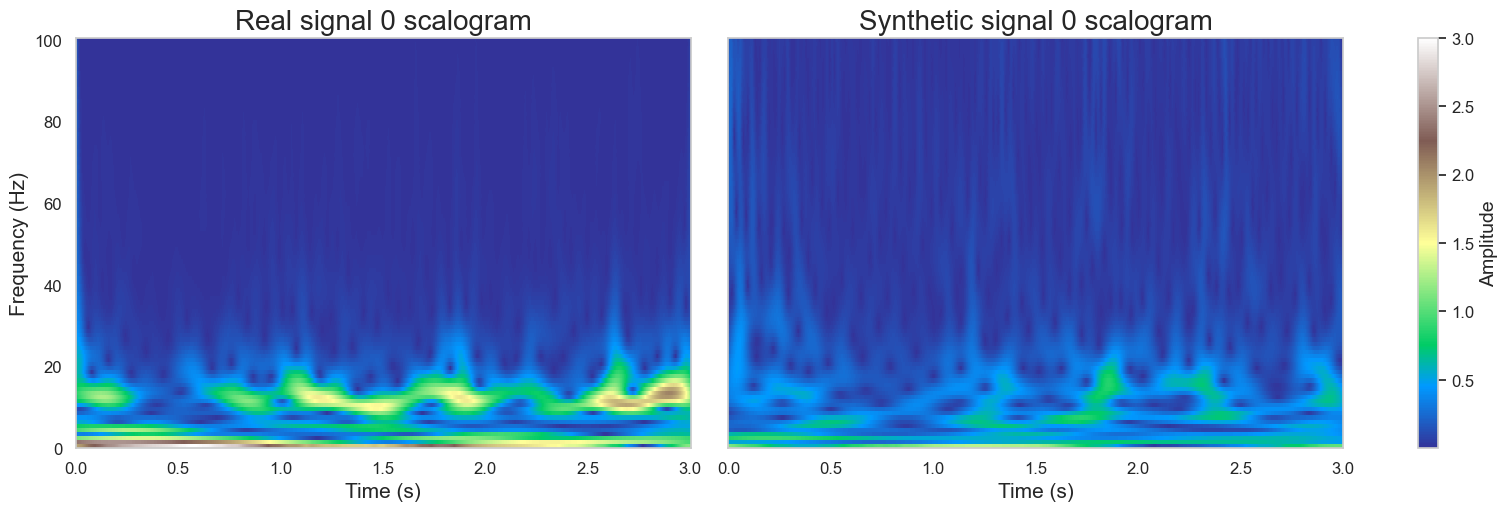

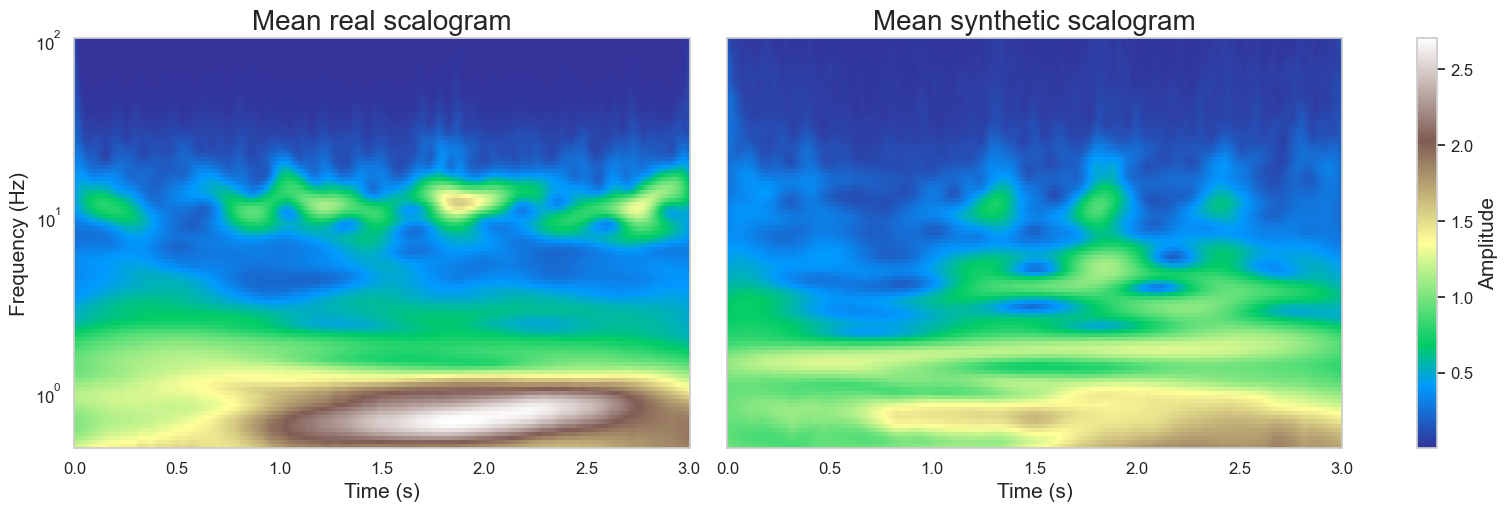

RR  | SSIM = 0.799 ± 0.0331 | NRMSE = 0.0736 ± 0.015 | Cosine = 0.825 ± 0.0519 | mode: all_vs_all, pairs: 190 (dataset)
RS  | SSIM = 0.721 ± 0.037 | NRMSE = 0.087 ± 0.0145 | Cosine = 0.731 ± 0.0537 | mode: all_vs_all, pairs: 400 (dataset)
SS  | SSIM = 0.703 ± 0.0719 | NRMSE = 0.0762 ± 0.0146 | Cosine = 0.8 ± 0.0663 | mode: all_vs_all, pairs: 190 (dataset)

=== Burst Statistics Summary ===
Band: 13–30 Hz | Threshold: percentile (p=75) | min_dur=100.0 ms | merge_gap=50.0 ms | smooth=50.0 ms
N_real=20 | N_synth=20

Feature                  RS WD     RR disp     SS disp
------------------------------------------------------
n_bursts                   0.2        0.61       0.685
rate_hz                 0.0667       0.203       0.228
mean_dur_s              0.0463      0.0517      0.0239
median_dur_s            0.0385      0.0572      0.0272
mean_peak                0.131        0.12      0.0682
median_peak               0.12       0.127      0.0635
mean_IBI_s                0.12        0.16

0.7836051500539222

In [6]:
# Initialize class
time_frequency_analysis = TimeFrequencyFidelity(fs=512)

# Plot scalograms
# At sample level
time_frequency_analysis.plot_scalograms(real_seg, synth_seg, signal_index_real=0, signal_index_synth=0)
# At dataset level
time_frequency_analysis.plot_mean_scalograms(real_seg,synth_seg, freq_scale="log")

# Compute time-frequency similarity metrics
# At dataset level
time_frequency_analysis.compute_scalogram_similarity_metrics(real_seg,synth_seg)
# At sample level
#time_frequency_analysis.compute_scalogram_similarity_metrics(real_data[0], synthetic_data[0])

# Compute burst statistics within the beta band
burst_results = time_frequency_analysis.compute_burst_statistics(real_seg, synth_seg, band=(13, 30))

# Compute time-frequency fidelity score
#evaluation_score.compute_time_frequency_fidelity_score(real_data[1], synthetic_data[3], fs=512)
evaluation_score.compute_time_frequency_fidelity_score(real_seg, synth_seg, fs=512, mode="all_vs_all")

#### 3.5. Complexity fidelity


MFDCCA Cross-Hurst Exponent (avg H(q)):
  real vs real:        1.3982 ± 0.0516
  real vs synthetic:   1.3375 ± 0.0675
  synthetic vs synthetic: 1.2916 ± 0.0883

MFDCCA Cross-Fluctuation F_xy(q) [averaged]:
  real vs real:        0.4383 ± 0.0753
  real vs synthetic:   0.3669 ± 0.0561
  synthetic vs synthetic: 0.3352 ± 0.0526

MFDCCA Width of Singularity Spectrum (Δα):
  real vs real:        0.9875 ± 0.1929
  real vs synthetic:   0.7079 ± 0.1837
  synthetic vs synthetic: 0.3415 ± 0.1489

MFDCCA Cross-Correlation Ratio p(q) [averaged over q]:
  real vs real:        1.0083 ± 0.0329
  real vs synthetic:   0.9486 ± 0.0266
  synthetic vs synthetic: 0.9099 ± 0.0206

MFDCCA Hurst Exponent:
  real vs real: Mean = 1.3982, Std = 0.0516
  real vs synthetic: Mean = 1.3375, Std = 0.0675
  synthetic vs synthetic: Mean = 1.2916, Std = 0.0883


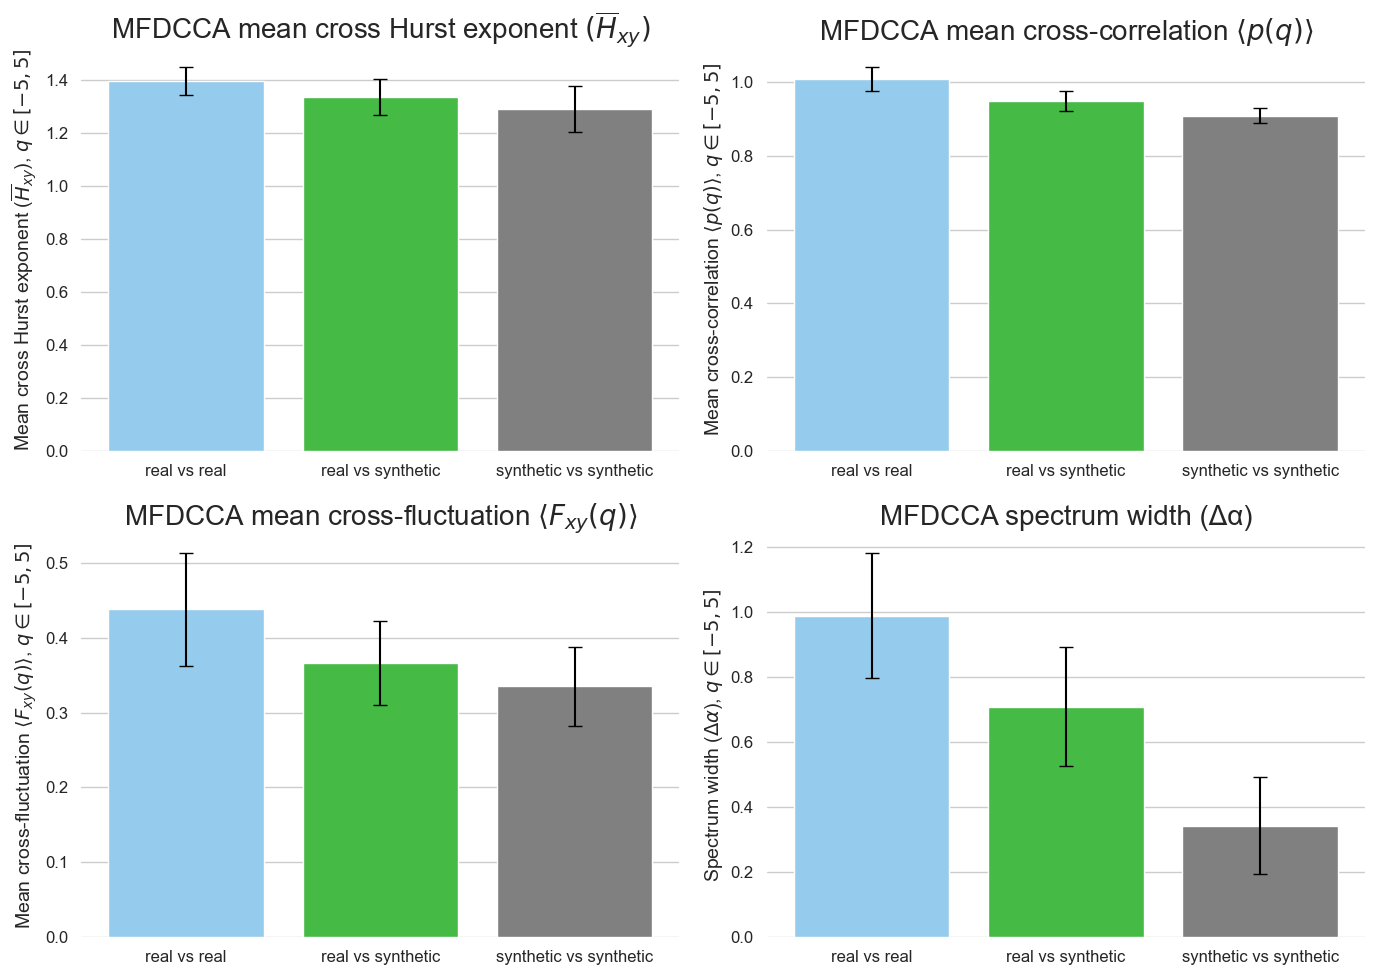

=== Entropy metrics ===
Wasserstein Distances (lower = more similar):
  SampEn WD: 0.423
  PermEn WD: 0.3784
  LZC   WD: 0.175
Means (Real vs Synthetic):
  SampEn: 0.3593 vs 0.7824
  PermEn: 0.612 vs 0.9904
  LZC   : 0.2157 vs 0.3907


DCCA Hurst Exponent (Hxy):
  real vs real: 1.2249 ± 0.0421
  real vs synthetic: 1.2402 ± 0.0706
  synthetic vs synthetic: 1.2701 ± 0.0993

DCCA Cross-Correlation Coefficient (ρ) :
  real vs real: 0.5058 ± 0.1528
  real vs synthetic: 0.0016 ± 0.0857
  synthetic vs synthetic: 0.2437 ± 0.2359

MFDFA Hurst Exponent:
  real: Mean = 1.6027, Std = 0.5585
  synthetic: Mean = 1.2922, Std = 0.1911

MFDCCA Cross-Hurst Exponent (avg H(q)):
  real vs real:        1.3982 ± 0.0516
  real vs synthetic:   1.3375 ± 0.0675
  synthetic vs synthetic: 1.2916 ± 0.0883

MFDCCA Cross-Fluctuation F_xy(q) [averaged]:
  real vs real:        0.4383 ± 0.0753
  real vs synthetic:   0.3669 ± 0.0561
  synthetic vs synthetic: 0.3352 ± 0.0526

MFDCCA Width of Singularity Spectrum (Δα):
  

0.7314827136033244

In [36]:
# Initialize class for MFDCCA method (for DCCA and MFDFA, specify method accordingly)
cf = ComplexityFidelity(real_seg, synth_seg, method='MFDCCA')

# Compute MFDCCA metrics
cf.compute_fractal_metrics()
# Plot MFDCCA metrics
cf.plot_metrics()

# Compute entropy metrics
entropy_metrics = cf.compute_entropy_complexity_metrics(real_seg, synth_seg)

# Compute complexity fidelity score
evaluation_score.compute_complexity_fidelity_score(real_seg, synth_seg)

#### 4. Diversity evaluation




[Manifold Coverage] Sigma: 11.4417
[Manifold Coverage] Coverage (real→synth): 0.677  (↑ better)
[Manifold Coverage] Outlier Goodness (synth→real): 0.645  (↑ better)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Geometric Diversity] PCA  -> Compactness: 0.689 | Mahalanobis Overlap: 0.153
[Geometric Diversity] UMAP -> Compactness: 0.812 | Mahalanobis Overlap: 0.007
[Intrinsic Diversity] Uniqueness (NN ratio, syn/real): 0.916  (~1 ideal; <1 collapse; >1 over-dispersion)
[Intrinsic Diversity] Global Diversity (pairwise ratio, syn/real): 0.960
[Intrinsic Diversity] Local Diversity P10 / P50 (NN ratio): 0.940 / 0.768


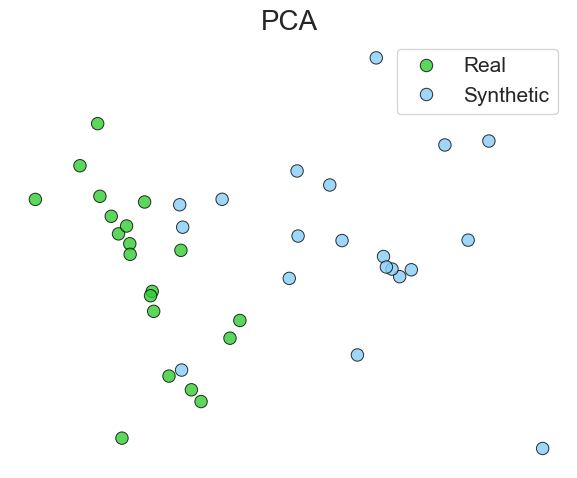

[Manifold Coverage] Sigma: 11.4417
[Manifold Coverage] Coverage (real→synth): 0.677  (↑ better)
[Manifold Coverage] Outlier Goodness (synth→real): 0.645  (↑ better)
[Geometric Diversity] PCA  -> Compactness: 0.689 | Mahalanobis Overlap: 0.153
[Geometric Diversity] UMAP -> Compactness: 0.812 | Mahalanobis Overlap: 0.007
[Intrinsic Diversity] Uniqueness (NN ratio, syn/real): 0.916  (~1 ideal; <1 collapse; >1 over-dispersion)
[Intrinsic Diversity] Global Diversity (pairwise ratio, syn/real): 0.960
[Intrinsic Diversity] Local Diversity P10 / P50 (NN ratio): 0.940 / 0.768
Diversity Score: 0.625
Coverage: 0.677
Outlier Goodness: 0.645
PCA Compactness: 0.689
UMAP Compactness: 0.812
PCA Overlap: 0.153
UMAP Overlap: 0.007
Uniqueness: 0.916
Local Diversity: 0.768
Global Diversity: 0.960


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


0.6252734230387101

In [7]:
# Initialize class
div = Diversity()

# Compute coverage diversity metrics
cov = div.compute_coverage_diversity(real_seg, synth_seg)

# Compute geometric diversity metrics
geom = div.compute_geometric_diversity(real_seg, synth_seg)

# Compute intrinsic diversity metrics
intr = div.compute_intrinsic_diversity(real_seg, synth_seg)

# Plot PCA and UMAP results
div.plot_embeddings("PCA", geom)
#div.plot_embeddings("UMAP", geom)

# Compute diversity score
evaluation_score.compute_diversity_score(real_seg, synth_seg)

#### 5. Privacy evaluation

In [9]:
# Initialize class
privacy_analysis = Privacy()

# Compute distance and MIR metrics
distance_metrics = privacy_analysis.compute_distance_metrics(real_seg, synth_seg)
mir = privacy_analysis.compute_mir(real_seg, synth_seg)

# Compute privacy score
evaluation_score.compute_privacy_score(real_seg, synth_seg)

📏 Distance Metrics Between Real and Synthetic Data:
  - Wasserstein Distance (WD): 0.0315 (min: 0.0072)
  - Euclidean Distance   (ED): 0.0644 (min: 0.0308)
  - Jensen–Shannon Divergence (JSD): 0.1471 (min: 0.0689)

🔐 Membership Inference Risk (MIR) Metrics:
🕵️ Attack via correctness: acc = 0.750
🕵️ Attack via confidence: acc = 0.900
🕵️ Attack via entropy: acc = 0.800
🕵️ Attack via modified entropy: acc = 0.900
  - Correctness Attack Acc: 0.75
  - Confidence Attack Acc: 0.9
  - Entropy Attack Acc: 0.8
  - Modified Entropy Attack Acc: 0.9
  - Synthetic Member Fraction: 0.0

🕵️ Attack via correctness: acc = 0.800
🕵️ Attack via confidence: acc = 1.000
🕵️ Attack via entropy: acc = 0.950
🕵️ Attack via modified entropy: acc = 1.000
Privacy Score: 0.06
  - WD Score:  0.03
  - ED Score:  0.06
  - JSD Score: 0.15
  - MIR Score: 0.00


0.05953278412719099